## Import Library & Data Load

In [1]:
import sys
print(sys.executable)

d:\aali-stock-price-forecasting-lstm\.venv\Scripts\python.exe


In [8]:
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, LSTM
from sklearn.metrics import mean_absolute_error

In [10]:
df_daily = pd.read_csv("data/AALI(daily).csv")
df_daily.head()

,timestamp,open,low,high,close,volume
0,2001-04-16,524,524,547,547,342131
1,2001-04-17,547,524,571,524,345804
2,2001-04-18,547,524,547,524,230361
3,2001-04-19,524,500,524,500,457574
4,2001-04-20,476,452,476,452,228262


## Visualization current Chart by dataset

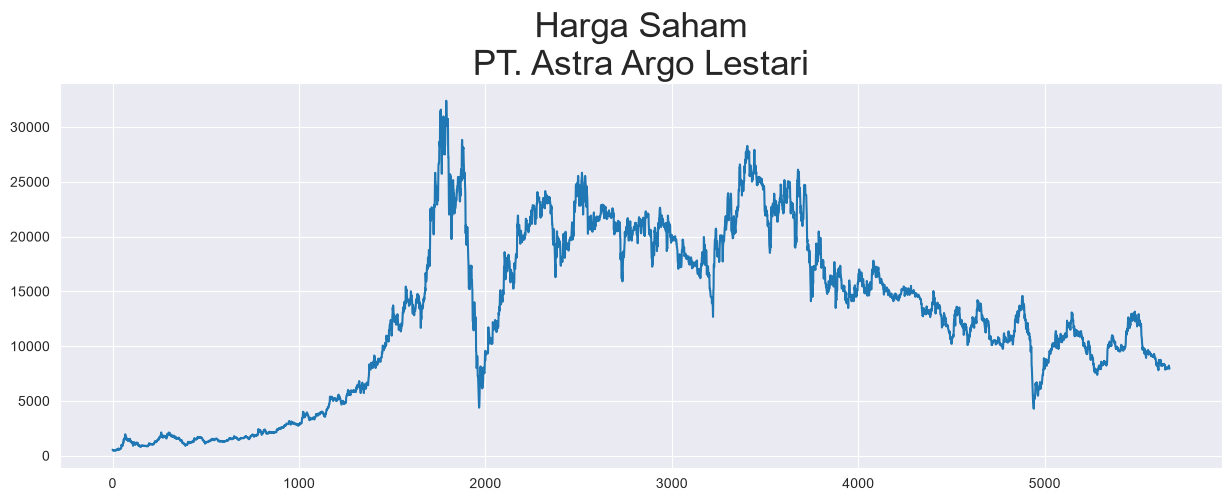

In [11]:
plt.figure(figsize=(15,5))
sns.set_style('darkgrid')
plt.plot(df_daily.index, df_daily['close'])
plt.title("Harga Saham\nPT. Astra Argo Lestari", fontsize=25)
plt.show()

## Transformation

In [12]:
ms = MinMaxScaler()
df_daily['close'] = ms.fit_transform(df_daily[['close']])

## Data Split

In [13]:
def split_data(df_daily, train_size):
  size = int(len(df_daily) * train_size)
  train, test = df_daily.iloc[0:size], df_daily.iloc[size:len(df_daily)]
  return train, test

In [14]:
train, test = split_data(df_daily['close'], 0.8) #80% Train

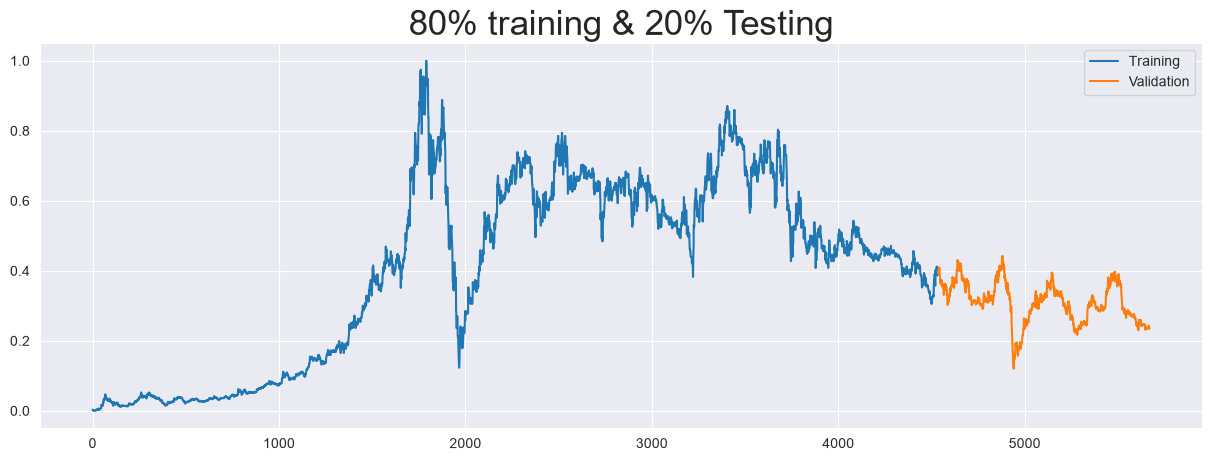

In [15]:
train, test = split_data(df_daily['close'], 0.8) #80% Train
plt.figure(figsize=(15,5))
plt.plot(train)
plt.plot(test)
plt.legend(labels=['Training', 'Validation'])
plt.title('80% training & 20% Testing', fontsize=25)
plt.show()

In [16]:
def split_target(df_daily, look_back=1):
    X, y = [], []
    for i in range(len(df_daily) - look_back):
        a = df_daily[i:(i + look_back), 0]
        X.append(a)
        y.append(df_daily[i + look_back, 0])
    return np.array(X), np.array(y)

In [17]:
X_train, y_train = split_target(train.values.reshape(len(train), 1))
X_test, y_test = split_target(test.values.reshape(len(test), 1))

In [18]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

## Build Model


In [19]:
model = Sequential([LSTM(100, input_shape=(1, 1), return_sequences=True),
                    LSTM(50),
                    Dense(25, activation='relu'),
                    Dense(1)])

d:\aali-stock-price-forecasting-lstm\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
class Callback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if logs.get('val_mae') is not None and logs.get('val_mae') < 0.015:
      self.model.stop_training = True

In [21]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              metrics=["mae"],
              loss=tf.keras.losses.Huber())

## Training Model

In [22]:
history = model.fit(X_train,
                    y_train,
                    epochs=2000,
                    batch_size=128,
                    validation_data=(X_test, y_test),
                    shuffle=False,
                    callbacks=[Callback()])

Epoch 1/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1100 - mae: 0.3943 - val_loss: 0.0424 - val_mae: 0.2857
Epoch 2/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1015 - mae: 0.3736 - val_loss: 0.0368 - val_mae: 0.2652
Epoch 3/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0927 - mae: 0.3546 - val_loss: 0.0310 - val_mae: 0.2426
Epoch 4/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0834 - mae: 0.3363 - val_loss: 0.0250 - val_mae: 0.2168
Epoch 5/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0731 - mae: 0.3164 - val_loss: 0.0189 - val_mae: 0.1869
Epoch 6/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0622 - mae: 0.2943 - val_loss: 0.0130 - val_mae: 0.1524
Epoch 7/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0509 - mae: 0.2697 - val_loss: 0.0077 - val_mae: 0.1141
Epoch 8/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0400 - mae: 0.2438 - val_loss: 0.0037 - val_mae: 0.0749
Epoch 9/2000
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

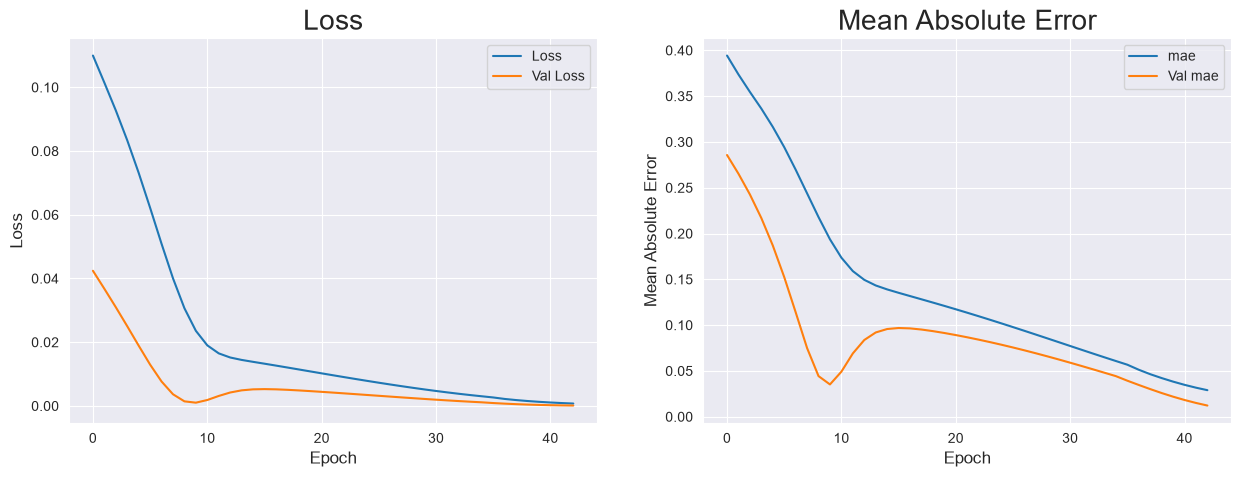

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

# Loss
ax1.plot(history.history['loss'])
ax1.plot(history.history['val_loss'])
ax1.legend(['Loss','Val Loss'])
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss', fontsize=20)

# MAE
ax2.plot(history.history['mae'])
ax2.plot(history.history['val_mae'])
ax2.legend(['mae','Val mae'])
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Mean Absolute Error', fontsize=12)
ax2.set_title('Mean Absolute Error', fontsize=20)
plt.show()

## Result

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


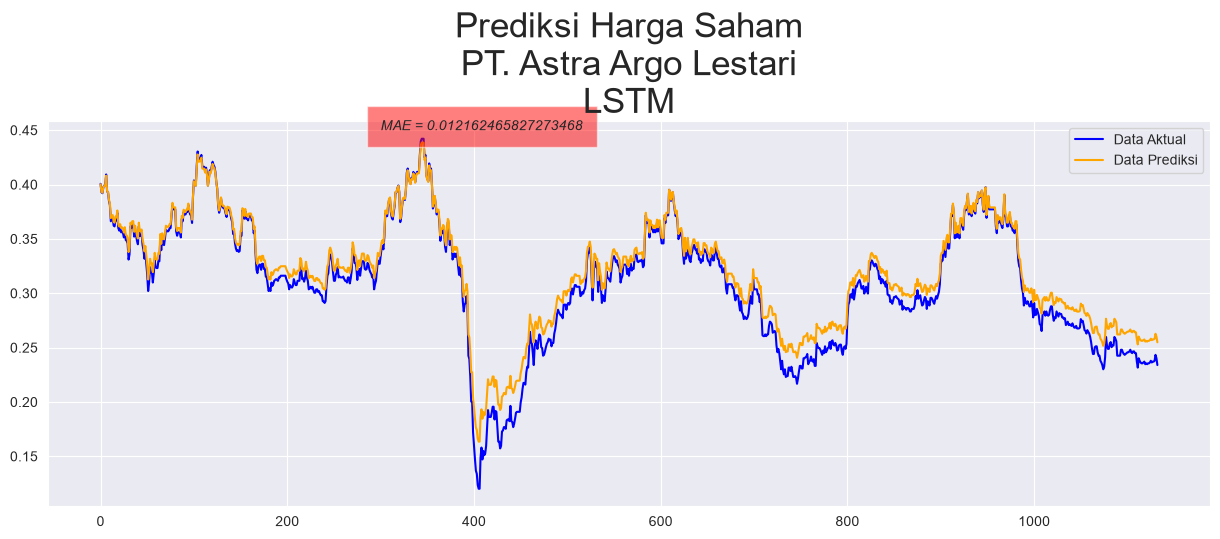

: 

In [ ]:
plt.figure(figsize=(15,5))
y_pred = model.predict(X_test)
y_pred = list(np.reshape(y_pred, (1,len(y_pred)))[0])

X_test = np.reshape(X_test, (len(X_test),1))
X_test = list(np.reshape(X_test, (1,len(X_test)))[0])

plt.plot(X_test, label='Data Aktual', color='blue')
plt.plot(y_pred, label='Data Prediksi', color='orange')
plt.text(300, 0.45, f"MAE = {mean_absolute_error(y_test, y_pred)}", style='italic', bbox={
        'facecolor': 'red', 'alpha': 0.5, 'pad': 10})
plt.title('Prediksi Harga Saham\nPT. Astra Argo Lestari\nLSTM', fontsize=25)
plt.legend()
plt.show()